# Exploratory Data Analysis (EDA) — Global Findex Database 2025

## Цель
Этот ноутбук выполняет исследовательский анализ файла `GlobalFindexDatabase2025.csv` для курсового проекта.

Исходный файл содержит не только данные по странам, но и значения показателей для демографических групп (пол, возраст, образование, доход, тип населённого пункта и т.д.). Для межстранового анализа ниже выделяется основной уровень наблюдения: **одна страна = одна строка**, с условиями `year = 2024`, `group = all`, `group2 = all`.

### Ключевые показатели для анализа
- `account_t_d` — общий уровень владения финансовым счётом;
- `mobileaccount_t_d` — владение мобильным денежным счётом;
- `dig_acc` — использование цифрового финансового счёта;
- `merchant_pay` — использование цифровых платежей торговцам;
- `fin4_d` — показатель, связанный с использованием цифровых финансовых сервисов;
- `internet` — использование интернета.

Значения долей в исходном файле хранятся в диапазоне **0–1** и в визуализациях дополнительно переводятся в проценты.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")

FILE = "GlobalFindexDatabase2025.csv"
raw = pd.read_csv(FILE, low_memory=False)
print(f"Исходный размер: {raw.shape[0]:,} строк × {raw.shape[1]:,} столбцов")

Исходный размер: 8,577 строк × 438 столбцов


## 1. Первичный обзор исходного файла

In [2]:
display(raw.head())

print("Распределение наблюдений по годам:")
display(raw["year"].value_counts().sort_index().to_frame("n_rows"))

print("Количество стран/экономик:", raw["codewb"].nunique())
print("Полных дубликатов:", raw.duplicated().sum())

,countrynewwb,codewb,year,pop_adult,regionwb24_hi,incomegroupwb24,group,group2,account_t_d,fiaccount_t_d,mobileaccount_t_d,borrow_any_t_d,fin4_d,dig_acc,fin11_2a,fin11a,fin11b,fin11c,fin11f,fin11d,fin11e,fin14a,fin14b,fin14c,fin14d,fin13_1a,fin13_1b,fin26a,fin26b,fin27a,fin27b,fin17f,fin17a_17a1_d,fin17a,fin17b,fin17c,fin22d,fin22e,fin22a_22a1_22g_d,fin22a,fin22a_22g,fin22a_1,fin22b,fin22c,fin24sav,fin24fam,fin24work,fin24bor,fin24sell,fin24other,...,con17a_s,con17b_s,con18_s,con19_s,con20_s,con21_s,con26d_s,con27_s,con28m_s,con30a_s,con30b_s,con30c_s,con30d_s,con30e_s,con30f_s,con30g_s,con30h_s,con31a_s,con31b_s,con31f_s,con2a_s,con15_s,con17d_s,con29_s,con31d_s,con31h_s,con32a_s,con3a_s,con4_s,con28d_s,con28w_s,con23_s,con31c_s,con2b_s,con2d_s,con26w_s,con2c_s,con2e_s,con2g_s,con5b_s,con12m_s,con26lm_s,con12w_s,con2f_s,con13_s,con26m_s,con28lm_s,con5a_s,con17c_s,con32h_s
0,Afghanistan,AFG,2011,14575546.0,South Asia (excluding high income),Low income,all,all,0.090050,0.090050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.028194,0.028194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,ALB,2011,2281010.0,Europe & Central Asia (excluding high income),Upper middle income,all,all,0.282681,0.282681,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.085616,0.085616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Algeria,DZA,2011,26251587.0,Middle East & North Africa (excluding high inc...,Lower middle income,all,all,0.332861,0.332861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.043257,0.043257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Angola,AGO,2011,12779501.0,Sub-Saharan Africa (excluding high income),Lower middle income,all,all,0.392035,0.392035,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.159156,0.159156,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,ARG,2011,30685516.0,Latin America & Caribbean (excluding high income),Upper middle income,all,all,0.331302,0.331302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.038007,0.038007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Распределение наблюдений по годам:


,n_rows
year,
2011,1516
2014,1686
2017,1734
2021,1483
2022,176
2024,1982


Количество стран/экономик: 174
Полных дубликатов: 0


### Вывод по структуре
Файл представляет собой **панельный и многомерный набор данных**: страны повторяются по годам и социально-демографическим группам. Поэтому использование всех 8577 строк одновременно для сравнения стран было бы некорректным: одна и та же страна встречается несколько раз.

## 2. Формирование аналитической выборки 2024 года

In [3]:
df = raw.query("year == 2024 and group == 'all' and group2 == 'all'").copy()

print(f"Размер аналитической выборки: {df.shape[0]} строк × {df.shape[1]} столбцов")
print(f"Уникальных стран/экономик: {df['codewb'].nunique()}")
print(f"Повторяющихся country codes: {df['codewb'].duplicated().sum()}")

display(df[["countrynewwb", "codewb", "year", "regionwb24_hi", "incomegroupwb24"]].head())

Размер аналитической выборки: 153 строк × 438 столбцов
Уникальных стран/экономик: 153
Повторяющихся country codes: 0


,countrynewwb,codewb,year,regionwb24_hi,incomegroupwb24
571,Albania,ALB,2024,Europe & Central Asia (excluding high income),Upper middle income
572,Algeria,DZA,2024,Middle East & North Africa (excluding high inc...,Lower middle income
573,Argentina,ARG,2024,Latin America & Caribbean (excluding high income),Upper middle income
574,Armenia,ARM,2024,Europe & Central Asia (excluding high income),Upper middle income
575,Australia,AUS,2024,High income,High income


## 3. Dataset overview: ключевые характеристики

In [4]:
overview = pd.DataFrame({
    "Feature": ["countrynewwb", "codewb", "year", "pop_adult", "regionwb24_hi", "incomegroupwb24"],
    "Description": [
        "Название страны или экономики",
        "Трёхбуквенный код World Bank",
        "Год наблюдения",
        "Численность взрослого населения",
        "Региональная классификация World Bank",
        "Группа стран по уровню дохода World Bank"
    ],
    "Type": ["categorical", "categorical", "numeric", "numeric", "categorical", "categorical"]
})
display(overview)

print("Типы данных:")
display(df.dtypes.value_counts().to_frame("n_columns"))

,Feature,Description,Type
0,countrynewwb,Название страны или экономики,categorical
1,codewb,Трёхбуквенный код World Bank,categorical
2,year,Год наблюдения,numeric
3,pop_adult,Численность взрослого населения,numeric
4,regionwb24_hi,Региональная классификация World Bank,categorical
5,incomegroupwb24,Группа стран по уровню дохода World Bank,categorical


Типы данных:


,n_columns
float64,431
object,6
int64,1


## 4. Анализ качества данных

In [5]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "non_null_count": df.notna().sum()
}).sort_values("missing_pct", ascending=False)

print("Топ-20 признаков с наибольшим числом пропусков:")
display(missing.head(20))

print("Количество признаков без пропусков:", (missing["missing_count"] == 0).sum())
print("Количество признаков с пропусками:", (missing["missing_count"] > 0).sum())

Топ-20 признаков с наибольшим числом пропусков:


,missing_count,missing_pct,non_null_count
fin32_33_34c_s,153,100.000000,0
fin37_39d_s,153,100.000000,0
fing2p_card_s,153,100.000000,0
fin32_n33_34d_s,153,100.000000,0
fin32_33_34d_s,153,100.000000,0
fin37_38_39d_s,153,100.000000,0
fin34d_s,153,100.000000,0
con12m_s,152,99.346405,1
fin32_33_34b_s,152,99.346405,1
con32h_s,152,99.346405,1


Количество признаков без пропусков: 10
Количество признаков с пропусками: 428


,missing_count,missing_pct,non_null_count
account_t_d,0,0.000000,153
internet,0,0.000000,153
dig_acc,45,29.411765,108
merchant_pay,45,29.411765,108
fin4_d,45,29.411765,108
mobileaccount_t_d,60,39.215686,93


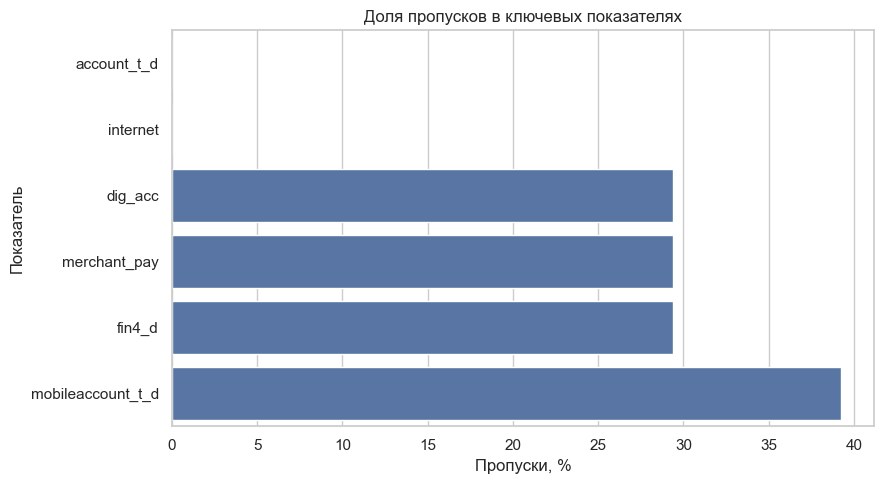

In [6]:
# Пропуски среди наиболее релевантных переменных
key_cols = ["account_t_d", "mobileaccount_t_d", "dig_acc", "merchant_pay", "fin4_d", "internet"]
key_cols = [c for c in key_cols if c in df.columns]

miss_key = missing.loc[key_cols].sort_values("missing_pct")
display(miss_key)

plt.figure(figsize=(9, 5))
sns.barplot(data=miss_key.reset_index(), x="missing_pct", y="index")
plt.title("Доля пропусков в ключевых показателях")
plt.xlabel("Пропуски, %")
plt.ylabel("Показатель")
plt.tight_layout()
plt.show()

## 5. Описательная статистика ключевых показателей

In [7]:
key_desc = df[key_cols].describe().T
key_desc["median"] = df[key_cols].median()
key_desc["missing_pct"] = df[key_cols].isna().mean() * 100

# Перевод долей в проценты для удобства интерпретации
for c in ["mean", "std", "min", "25%", "50%", "median", "75%", "max"]:
    if c in key_desc.columns:
        key_desc[c] = key_desc[c] * 100

display(key_desc.round(2))

,count,mean,std,min,25%,50%,75%,max,median,missing_pct
account_t_d,153.0,70.72,22.30,14.83,54.52,73.10,89.60,99.85,73.10,0.00
mobileaccount_t_d,93.0,30.80,20.24,2.65,13.10,28.80,47.40,87.50,28.80,39.22
dig_acc,108.0,46.58,21.22,7.43,29.17,47.66,62.05,96.20,47.66,29.41
merchant_pay,108.0,28.44,22.26,2.42,9.97,20.40,44.28,94.94,20.40,29.41
fin4_d,108.0,29.98,20.71,1.83,11.56,24.44,44.71,73.20,24.44,29.41
internet,153.0,73.20,23.22,11.06,59.78,82.91,90.23,99.12,82.91,0.00


### Интерпретация
Для процентных показателей среднее характеризует типичный уровень распространения услуги среди стран, медиана менее чувствительна к экстремальным значениям, а разница между минимумом и максимумом показывает международную неоднородность.

## 6. Распределения ключевых показателей

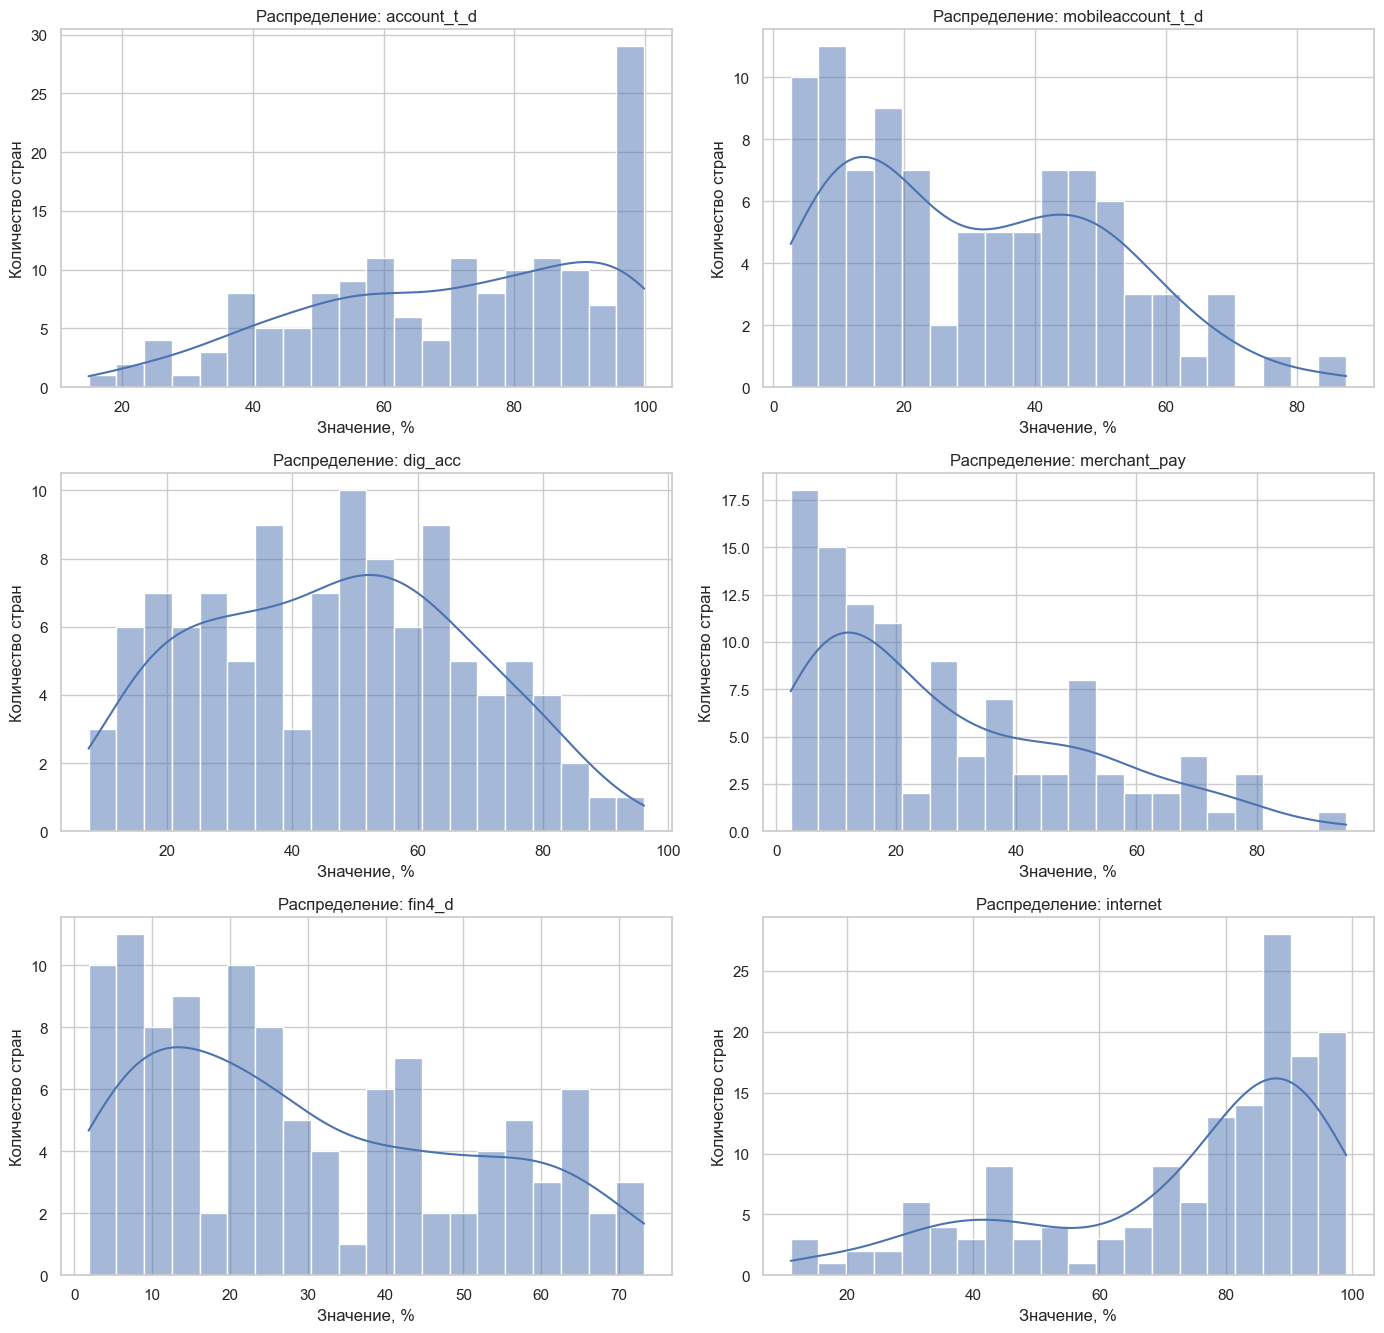

In [8]:
plot_df = df[key_cols].copy() * 100
ncols = 2
nrows = int(np.ceil(len(key_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, key_cols):
    sns.histplot(plot_df[col].dropna(), bins=20, kde=True, ax=ax)
    ax.set_title(f"Распределение: {col}")
    ax.set_xlabel("Значение, %")
    ax.set_ylabel("Количество стран")

for ax in axes[len(key_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

## 7. Boxplot-анализ и потенциальные выбросы

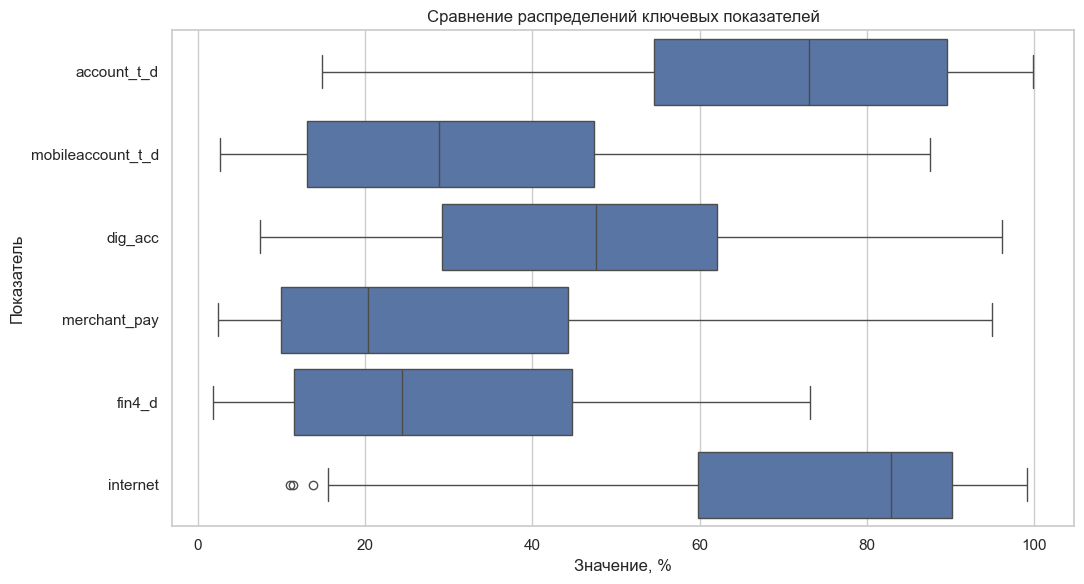

In [9]:
long_df = plot_df.melt(var_name="feature", value_name="value").dropna()
plt.figure(figsize=(11, 6))
sns.boxplot(data=long_df, x="value", y="feature")
plt.title("Сравнение распределений ключевых показателей")
plt.xlabel("Значение, %")
plt.ylabel("Показатель")
plt.tight_layout()
plt.show()

Boxplot используется здесь не для автоматического удаления выбросов. Для межстрановых данных очень высокие или низкие значения часто отражают реальные различия между странами, а не ошибки данных.

## 8. Анализ региональной структуры

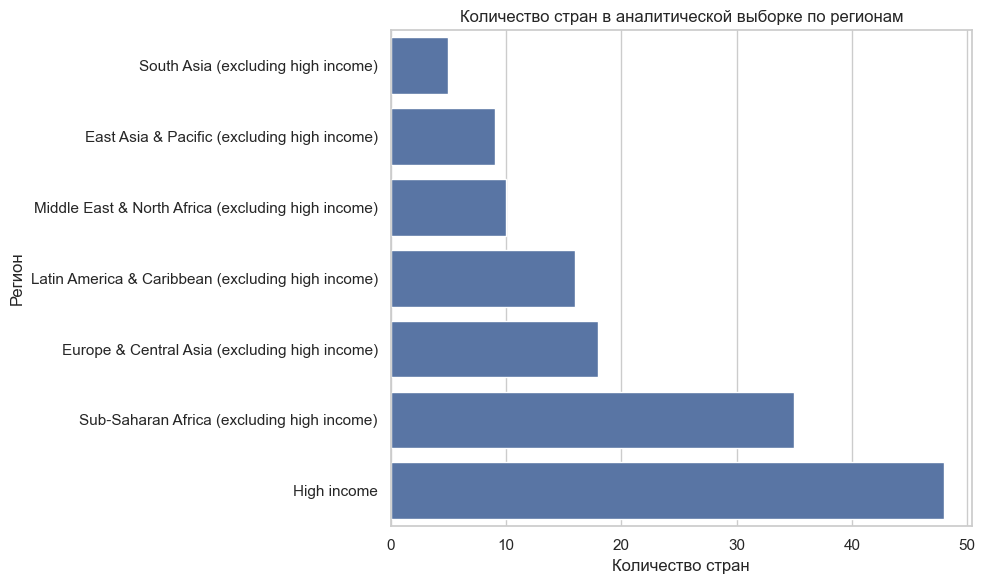

,n_countries
regionwb24_hi,
South Asia (excluding high income),5
East Asia & Pacific (excluding high income),9
Middle East & North Africa (excluding high income),10
Latin America & Caribbean (excluding high income),16
Europe & Central Asia (excluding high income),18
Sub-Saharan Africa (excluding high income),35
High income,48


In [10]:
region_counts = df["regionwb24_hi"].value_counts().sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(x=region_counts.values, y=region_counts.index)
plt.title("Количество стран в аналитической выборке по регионам")
plt.xlabel("Количество стран")
plt.ylabel("Регион")
plt.tight_layout()
plt.show()

display(region_counts.to_frame("n_countries"))

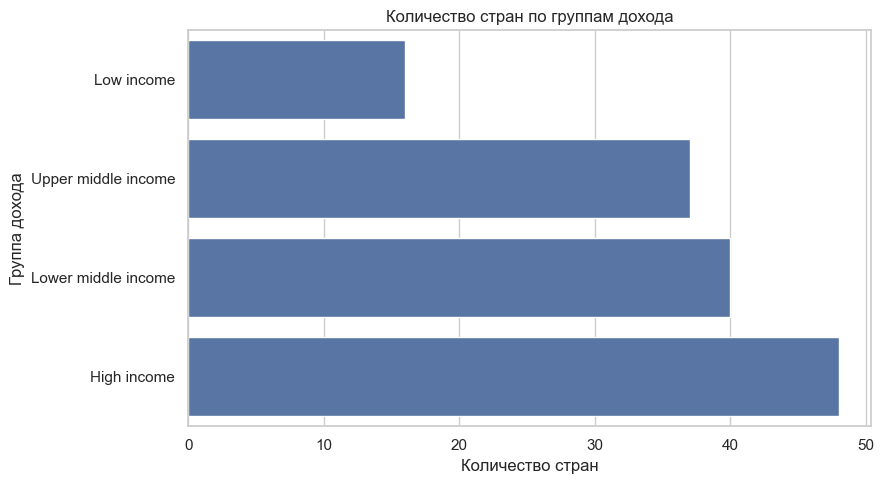

In [11]:
income_counts = df["incomegroupwb24"].value_counts().sort_values()
plt.figure(figsize=(9, 5))
sns.barplot(x=income_counts.values, y=income_counts.index)
plt.title("Количество стран по группам дохода")
plt.xlabel("Количество стран")
plt.ylabel("Группа дохода")
plt.tight_layout()
plt.show()

## 9. Сравнение ключевых показателей по регионам

,account_t_d,mobileaccount_t_d,dig_acc,merchant_pay,fin4_d,internet
regionwb24_hi,,,,,,
South Asia (excluding high income),60.26,15.16,25.15,9.88,23.70,43.62
Middle East & North Africa (excluding high income),42.41,9.82,25.41,15.57,21.97,78.23
Latin America & Caribbean (excluding high income),59.93,24.44,42.84,29.65,32.45,81.99
Sub-Saharan Africa (excluding high income),55.60,43.13,48.31,17.25,12.78,41.33
Europe & Central Asia (excluding high income),72.19,23.47,50.52,40.98,50.51,84.20
East Asia & Pacific (excluding high income),69.10,33.56,56.28,44.17,42.89,80.67
High income,91.64,47.01,67.14,55.55,52.91,91.62


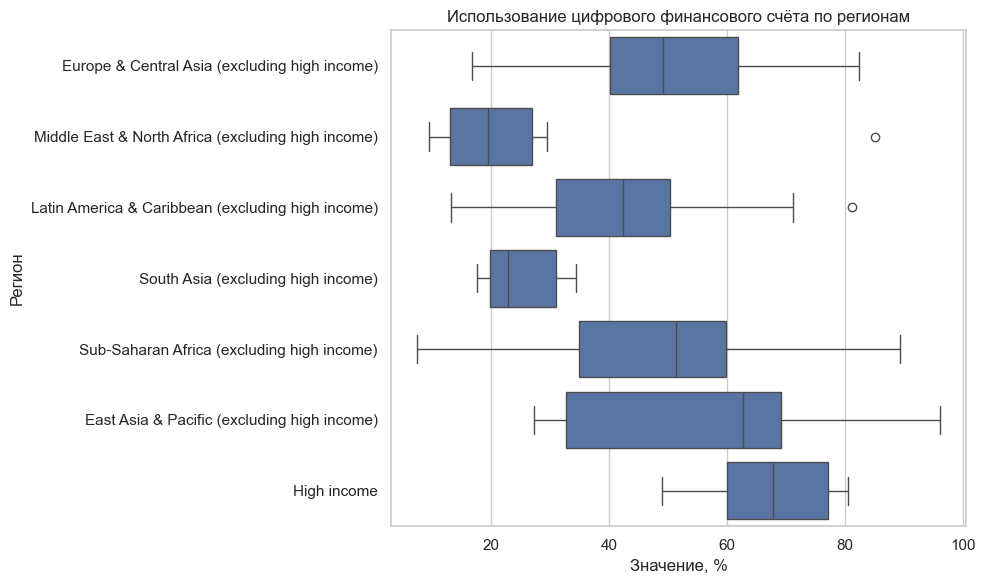

In [12]:
region_metrics = df.groupby("regionwb24_hi")[key_cols].mean() * 100
region_metrics = region_metrics.sort_values("dig_acc") if "dig_acc" in region_metrics else region_metrics
display(region_metrics.round(2))

if "dig_acc" in df.columns:
    plt.figure(figsize=(10, 6))
    temp = df[["regionwb24_hi", "dig_acc"]].dropna().copy()
    temp["dig_acc"] *= 100
    sns.boxplot(data=temp, x="dig_acc", y="regionwb24_hi")
    plt.title("Использование цифрового финансового счёта по регионам")
    plt.xlabel("Значение, %")
    plt.ylabel("Регион")
    plt.tight_layout()
    plt.show()

## 10. Сравнение показателей по уровню дохода страны

,account_t_d,mobileaccount_t_d,dig_acc,merchant_pay,fin4_d,internet
incomegroupwb24,,,,,,
High income,91.64,47.01,67.14,55.55,52.91,91.62
Low income,45.45,36.14,38.42,8.89,6.23,30.70
Lower middle income,56.34,29.97,41.55,21.98,22.06,62.31
Upper middle income,69.48,30.80,51.23,37.67,43.53,81.54


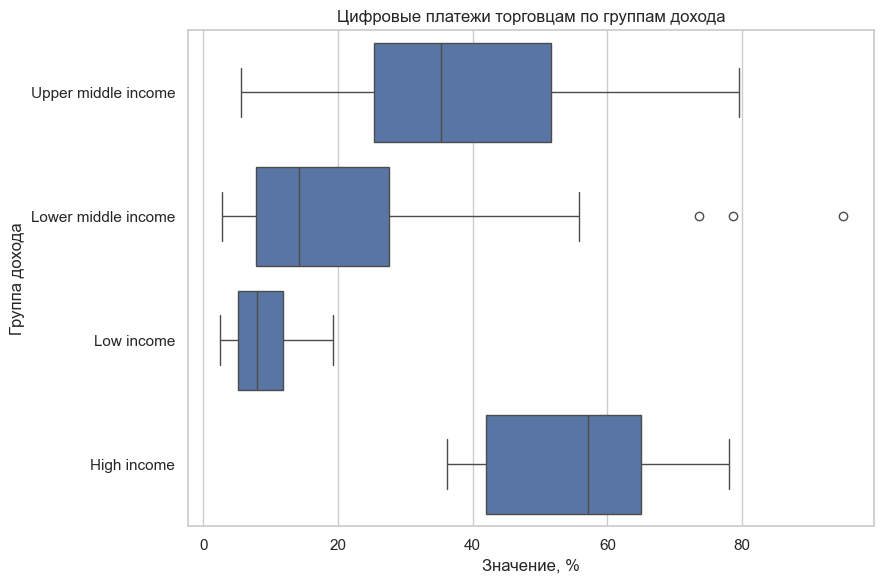

In [13]:
income_metrics = df.groupby("incomegroupwb24")[key_cols].mean() * 100
display(income_metrics.round(2))

if "merchant_pay" in df.columns:
    temp = df[["incomegroupwb24", "merchant_pay"]].dropna().copy()
    temp["merchant_pay"] *= 100
    plt.figure(figsize=(9, 6))
    sns.boxplot(data=temp, x="merchant_pay", y="incomegroupwb24")
    plt.title("Цифровые платежи торговцам по группам дохода")
    plt.xlabel("Значение, %")
    plt.ylabel("Группа дохода")
    plt.tight_layout()
    plt.show()

## 11. Корреляционный анализ

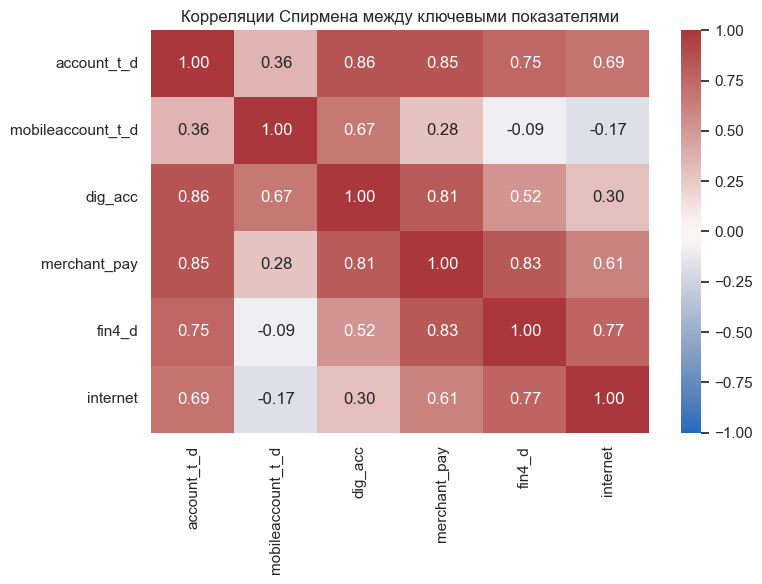

spearman_correlation
account_t_d       dig_acc                   0.855612
                  merchant_pay              0.845380
merchant_pay      fin4_d                    0.830709
dig_acc           merchant_pay              0.812970
fin4_d            internet                  0.765822
account_t_d       fin4_d                    0.753246
                  internet                  0.690533
mobileaccount_t_d dig_acc                   0.671484
merchant_pay      internet                  0.610659
dig_acc           fin4_d                    0.520116

In [14]:
corr_data = df[key_cols].copy()
corr = corr_data.corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="vlag", vmin=-1, vmax=1)
plt.title("Корреляции Спирмена между ключевыми показателями")
plt.tight_layout()
plt.show()

# Сильнейшие пары
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pairs = pairs.reindex(pairs.abs().sort_values(ascending=False).index)
display(pairs.head(10).to_frame("spearman_correlation"))

## 12. Связь цифровой инфраструктуры и цифровых финансов

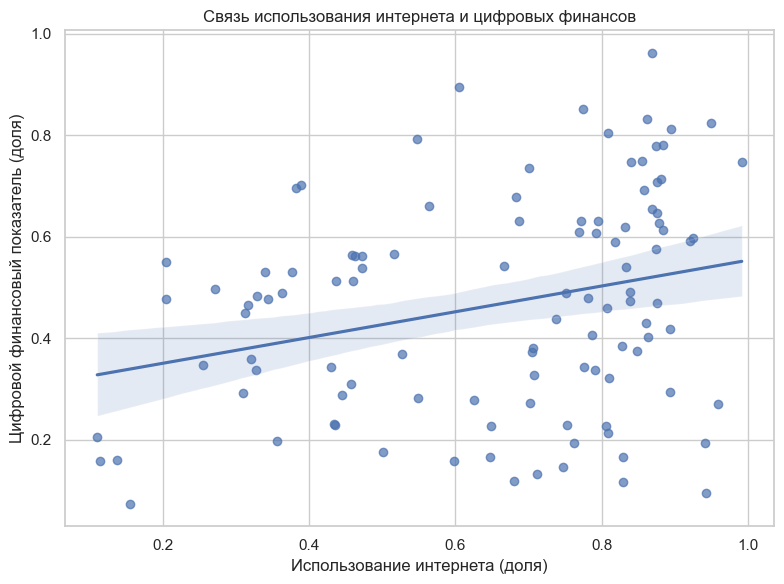

Корреляция Спирмена: 0.305


In [15]:
# Scatter plot: internet vs digital financial adoption
if "internet" in df.columns and "dig_acc" in df.columns:
    temp = df[["countrynewwb", "internet", "dig_acc"]].dropna().copy()
    plt.figure(figsize=(8, 6))
    sns.regplot(data=temp, x="internet", y="dig_acc", scatter_kws={"alpha": 0.7})
    plt.title("Связь использования интернета и цифровых финансов")
    plt.xlabel("Использование интернета (доля)")
    plt.ylabel("Цифровой финансовый показатель (доля)")
    plt.tight_layout()
    plt.show()
    print("Корреляция Спирмена:", temp[["internet", "dig_acc"]].corr(method="spearman").iloc[0, 1].round(3))

## 13. Рейтинг стран по ключевому цифровому показателю

,countrynewwb,regionwb24_hi,dig_acc
657,Mongolia,East Asia & Pacific (excluding high income),0.962049
636,Kenya,Sub-Saharan Africa (excluding high income),0.894039
628,"Iran, Islamic Rep.",Middle East & North Africa (excluding high inc...,0.851176
594,China,East Asia & Pacific (excluding high income),0.832148
701,Ukraine,Europe & Central Asia (excluding high income),0.823869
707,"Venezuela, RB",Latin America & Caribbean (excluding high income),0.811894
676,Poland,High income,0.805034
618,Ghana,Sub-Saharan Africa (excluding high income),0.792805
635,Kazakhstan,Europe & Central Asia (excluding high income),0.779810
601,Croatia,High income,0.779412


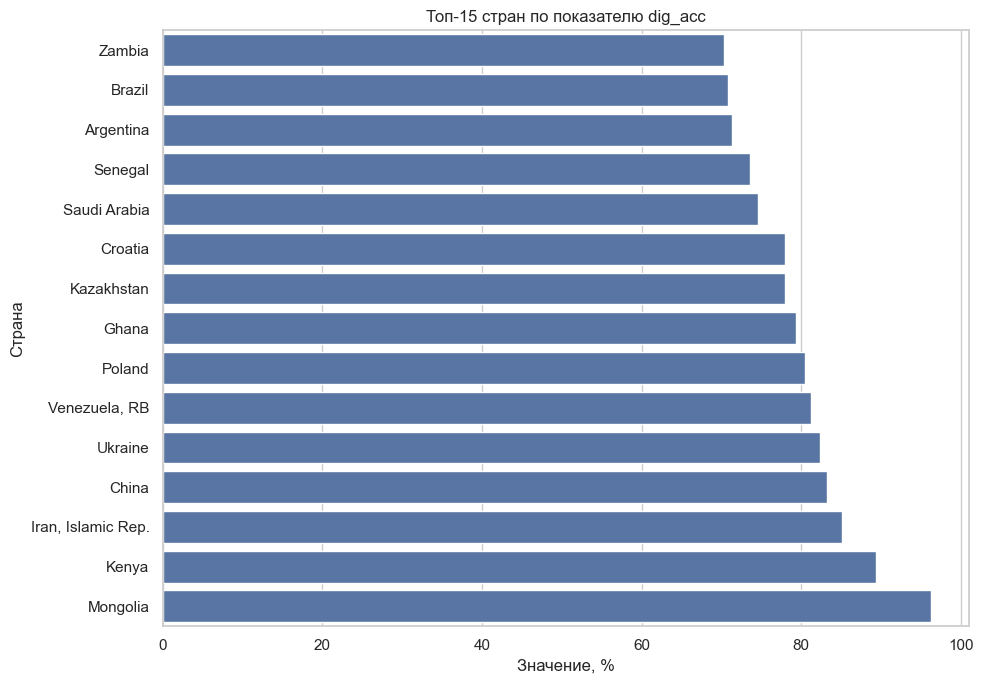

In [16]:
RANK_COL = "dig_acc" if "dig_acc" in df.columns else key_cols[0]
rank = df[["countrynewwb", "regionwb24_hi", RANK_COL]].dropna().sort_values(RANK_COL, ascending=False)
rank_pct = rank.head(15).sort_values(RANK_COL).copy()
rank_pct[RANK_COL] *= 100

display(rank.head(15))

plt.figure(figsize=(10, 7))
sns.barplot(data=rank_pct, x=RANK_COL, y="countrynewwb")
plt.title(f"Топ-15 стран по показателю {RANK_COL}")
plt.xlabel("Значение, %")
plt.ylabel("Страна")
plt.tight_layout()
plt.show()

## 14. Итоговые выводы для курсового проекта

In [17]:
print("ОСНОВНЫЕ ХАРАКТЕРИСТИКИ АНАЛИТИЧЕСКОЙ ВЫБОРКИ")
print("- Стран/экономик:", df["codewb"].nunique())
print("- Год:", df["year"].unique())
print("- Столбцов в исходном файле:", raw.shape[1])
print("- Строк после фильтрации до country-level:", len(df))
print("- Полных дубликатов после фильтрации:", df.duplicated().sum())

print("\nСредние значения ключевых показателей, %:")
print((df[key_cols].mean()*100).sort_values(ascending=False).round(2))

ОСНОВНЫЕ ХАРАКТЕРИСТИКИ АНАЛИТИЧЕСКОЙ ВЫБОРКИ
- Стран/экономик: 153
- Год: [2024]
- Столбцов в исходном файле: 438
- Строк после фильтрации до country-level: 153
- Полных дубликатов после фильтрации: 0

Средние значения ключевых показателей, %:
internet             73.20
account_t_d          70.72
dig_acc              46.58
mobileaccount_t_d    30.80
fin4_d               29.98
merchant_pay         28.44
dtype: float64


### Что можно использовать в дальнейшем исследовании
1. **Основная аналитическая единица:** страна/экономика в 2024 году.
2. **Главные цифровые признаки:** `dig_acc`, `merchant_pay`, `mobileaccount_t_d` и другие показатели цифрового финансового поведения.
3. **Контекстные признаки:** `internet`, регион и группа дохода.
4. **Перед объединением с Economic Freedom Index:** необходимо стандартизировать названия или использовать трёхбуквенные коды стран (`codewb`).
5. **Следующий этап:** выбрать 1 основную FinTech-метрику, объединить country-level выборку с Economic Freedom Index и проверить статистическую связь с помощью scatter plot, корреляции и регрессионного анализа.